# CATHODE, CDOT, LaCATHODE Data Production

This Jupyter notebook goes through the process of applying CATHODE, CATHODE + CDOT, LaCATHODE on a simulated dataset. It produces the data required to later analyse using plots etc.


# New Additions for V5

- Added the inverse quantile to transform h distribution back to original (CATHODE and Supervised)
- Add logit transformation before applying CDOT to transformed classifier

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import random
import subprocess
import sys
import statsmodels.api as sm

from os.path import exists, join, dirname, realpath
from sklearn.metrics import roc_curve
from sklearn.neighbors import KernelDensity
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle

# adding parent directory to path
parent_dir = dirname(realpath(globals()["_dh"][0]))
sys.path.append(parent_dir)

from sk_cathode.generative_models.conditional_normalizing_flow_torch import ConditionalNormalizingFlow
from sk_cathode.classifier_models.neural_network_classifier import NeuralNetworkClassifier
from sk_cathode.utils.preprocessing import LogitScaler

# from cdot.CDOT_Functions import fit_cdot, predict_cdot, fit_cdot_kernel

In [3]:
# :sunglasses:
plt.style.use('dark_background')

In [4]:
np.random.seed(42)

In [5]:
# Import w-tagging data
train_df = pd.read_csv("WTaggingTrain.csv", index_col = 0)
val_df = pd.read_csv("WTaggingVal.csv", index_col = 0)
test_df = pd.read_csv("WTaggingTest.csv", index_col = 0)

# Make background label 0 and signal label 1
train_df["label"] = 1- train_df["label"]
val_df["label"] = 1 - val_df["label"]
test_df["label"] = 1 - test_df["label"]

In [6]:
# Change label column name to signal

train_df.rename(columns = {"label" : "signal"}, inplace = True)

val_df.rename(columns = {"label" : "signal"}, inplace = True)

test_df.rename(columns = {"label" : "signal"}, inplace = True)

In [7]:
# Decide the SR by keepin 80% of the signal data within the SR

lower_sr = np.quantile(train_df["mass"][train_df["signal"] == 1], 0.1)
upper_sr = np.quantile(train_df["mass"][train_df["signal"] == 1], 0.9)

In [8]:
random.seed(42)

# Range of SR
SR = (lower_sr, upper_sr)

# Extract SR and SB data
innerdata_train_df = train_df[(train_df["mass"] >= SR[0]) & (train_df["mass"] <= SR[1])]
outerdata_train_df = train_df[(train_df["mass"] < SR[0]) | (train_df["mass"] > SR[1])]

innerdata_val_df = val_df[(val_df["mass"] >= SR[0]) & (val_df["mass"] <= SR[1])]
outerdata_val_df = val_df[(val_df["mass"] < SR[0]) | (val_df["mass"] > SR[1])]

innerdata_test_df = test_df[(test_df["mass"] >= SR[0]) & (test_df["mass"] <= SR[1])]
outerdata_test_df = test_df[(test_df["mass"] < SR[0]) | (test_df["mass"] > SR[1])]

# Convert to numpy 2d arrays
innerdata_train = innerdata_train_df.to_numpy()
outerdata_train = outerdata_train_df.to_numpy()

innerdata_val = innerdata_val_df.to_numpy()
outerdata_val = outerdata_val_df.to_numpy()

innerdata_test = innerdata_test_df.to_numpy()
outerdata_test = outerdata_test_df.to_numpy()

In [9]:
# Define a column for whether or not that data point falls inside the SR or not

# Train Data
train_df["SR"] = (train_df["mass"] >= SR[0]) & (train_df["mass"] <= SR[1])
train_df["SR"] = train_df["SR"].astype(int)

# Validation Data
val_df["SR"] = (val_df["mass"] >= SR[0]) & (val_df["mass"] <= SR[1])
val_df["SR"] = val_df["SR"].astype(int)

# Test Data
test_df["SR"] = (test_df["mass"] >= SR[0]) & (test_df["mass"] <= SR[1])
test_df["SR"] = test_df["SR"].astype(int)

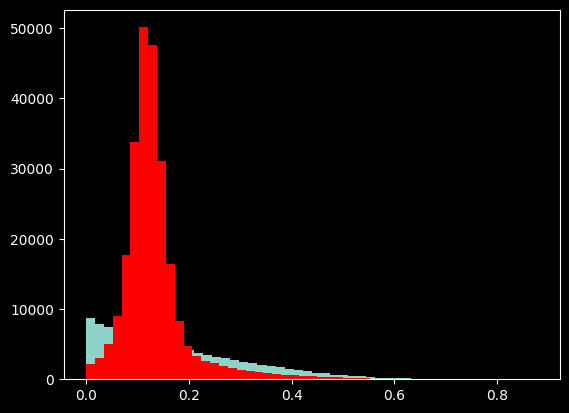

In [10]:
plt.hist(train_df["mass"][train_df["signal"] == 0], bins = 50)
plt.hist(train_df["mass"][train_df["signal"] == 1], bins = 50, color = "red")
plt.show()

# Density Estimation

We first start by training the conditional normalizing flow for *density estimation* the SB data (assumed to be background A.K.A $p_{background}$).

In [11]:
# either train new flow model from scratch

# We streamline the preprocessing with an sklearn pipeline.
# Ideally we would wrap the whole model, including the flow. But out of the box,
# the pipeline class does not wrap sample() and predict_log_proba() :(
# outer_scaler = make_pipeline(LogitScaler(), StandardScaler())

m_train = outerdata_train[:, 0:1]
# X_train = outer_scaler.fit_transform(outerdata_train[:, 1:-1])
X_train = outerdata_train[:, 1:-1]
m_val = outerdata_val[:, 0:1]
# X_val = outer_scaler.transform(outerdata_val[:, 1:-1])
X_val = outerdata_val[:, 1:-1]

flow_savedir = "./trained_flows_deltaR/"
# Let's protect ourselves from accidentally overwriting a trained model.
if not exists(join(flow_savedir, "DE_models")):
    flow_model = ConditionalNormalizingFlow(save_path=flow_savedir,
                                            num_inputs=outerdata_train[:, 1:-1].shape[1],
                                            early_stopping=True, epochs=None,
                                            verbose=True)
    flow_model.fit(X_train, m_train, X_val, m_val)
else:
    print(f"The model exists already in {flow_savedir}. Remove first if you want to overwrite.")

The model exists already in ./trained_flows_deltaR/. Remove first if you want to overwrite.


In [12]:
# or loading existing flow model


flow_savedir = "./trained_flows_deltaR/"
flow_model = ConditionalNormalizingFlow(save_path=flow_savedir,
                                        num_inputs=outerdata_train[:, 1:-1].shape[1],
                                        load=True)

ConditionalNormalizingFlow has 309720 parameters
The best epoch is 99.


Using the normalizing flow sample data points within the SR.

In [13]:
# fitting a KDE for the mass distribution based on the inner training set

# we also perform a logit first to stretch out the hard boundaries
# m_scaler = LogitScaler(epsilon=1e-8)
# m_train = m_scaler.fit_transform(innerdata_train[:, 0:1])
m_train = innerdata_train[:, 0:1]

kde_model = KernelDensity(bandwidth=0.01, kernel='gaussian')
kde_model.fit(m_train)

# now let's sample 4x the number of training data
m_samples = kde_model.sample(4*len(m_train)).astype(np.float32)
# m_samples = m_scaler.inverse_transform(m_samples)

# drawing samples from the flow model with the KDE samples as conditional
X_samples = flow_model.sample(n_samples=len(m_samples), m=m_samples)

# X_samples = outer_scaler.inverse_transform(X_samples)

# assigning "signal" label 0 to samples
samples = np.hstack([m_samples, X_samples, np.zeros((m_samples.shape[0], 1))])

In [14]:
cathode_samples_df = pd.DataFrame(np.hstack([m_samples, X_samples]), columns = list(train_df.columns)[0:11])

# Density Estimation Sanity Check
Plot the histograms of the "true" data background and the sample background from the normalizing flow for each variable/feature. 
This is utilised as a sanity check to gauge how well the normalizing flow has estimated the data's distribution.

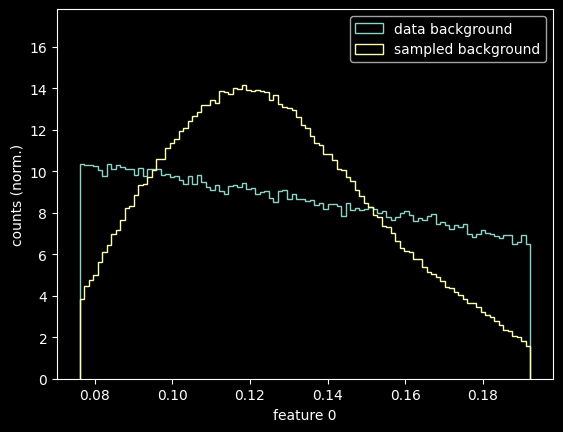

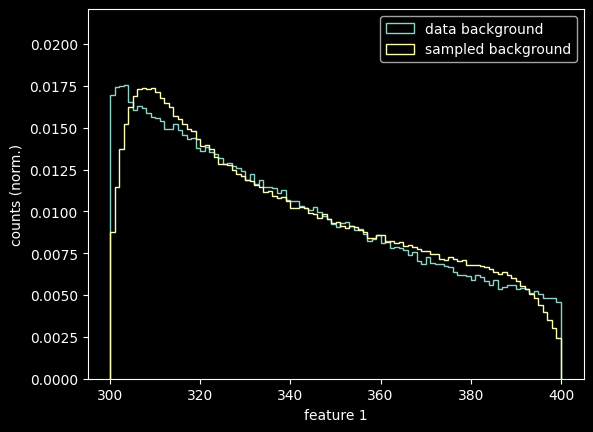

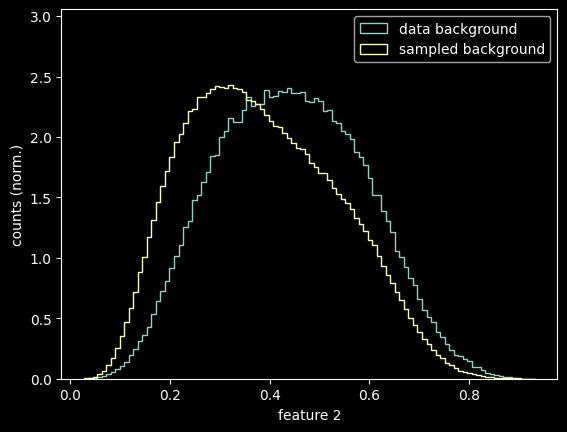

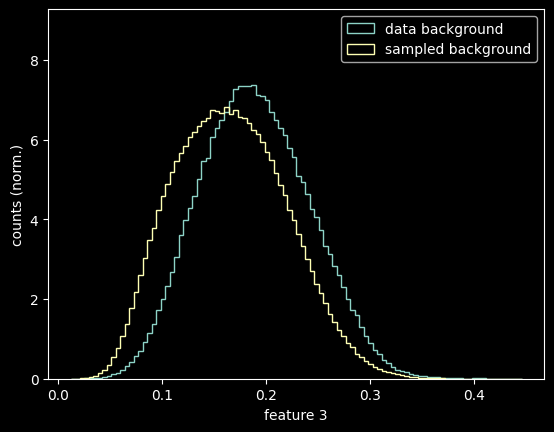

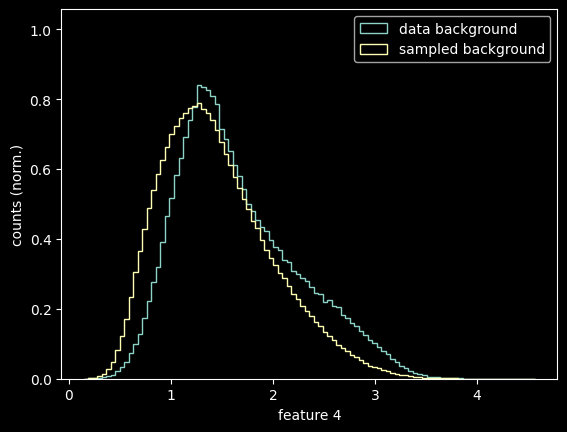

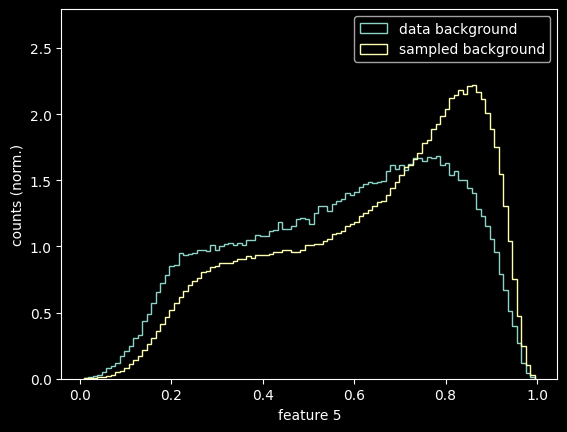

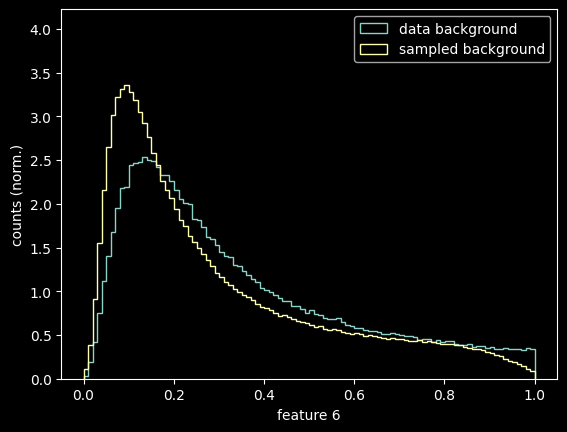

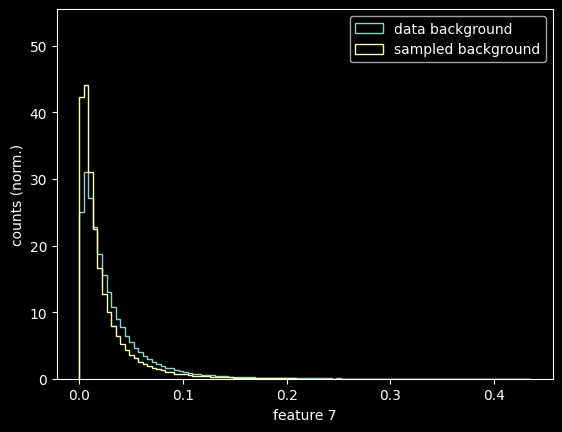

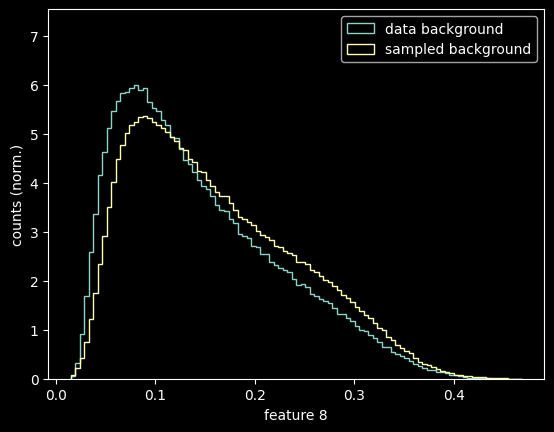

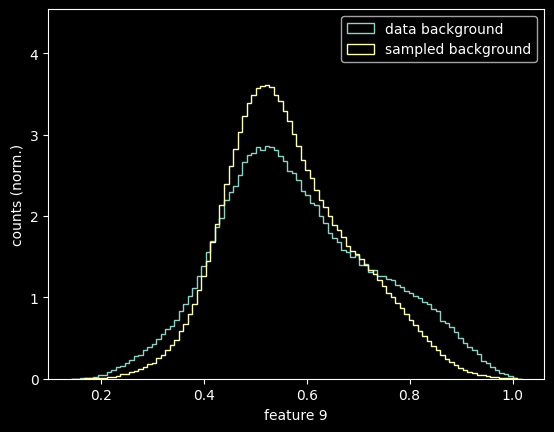

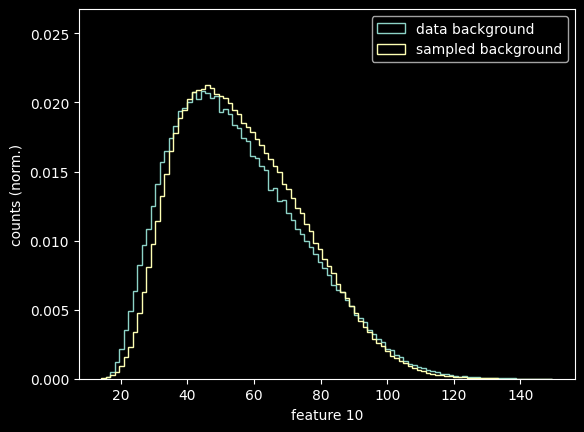

In [15]:
# comparing samples to inner background (idealized sanity check)

for i in range(innerdata_test[:, :-1].shape[1]):
    _, binning, _ = plt.hist(innerdata_test[innerdata_test[:, -1] == 0, i],
                             bins=100, label="data background",
                             density=True, histtype="step")
    _ = plt.hist(samples[:, i],
                 bins=binning, label="sampled background",
                 density=True, histtype="step")
    plt.legend()
    plt.ylim(0, plt.gca().get_ylim()[1] * 1.2)
    plt.xlabel("feature {}".format(i))
    plt.ylabel("counts (norm.)")
    plt.show()

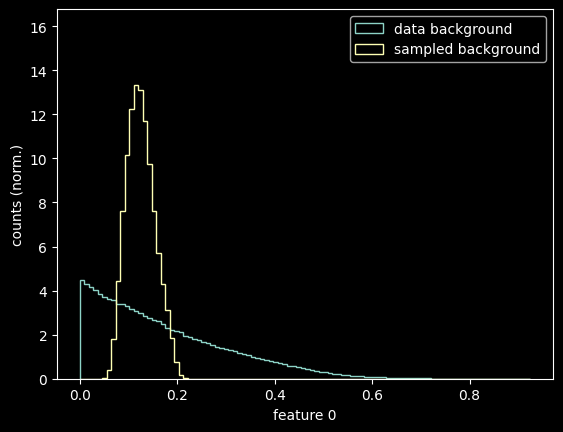

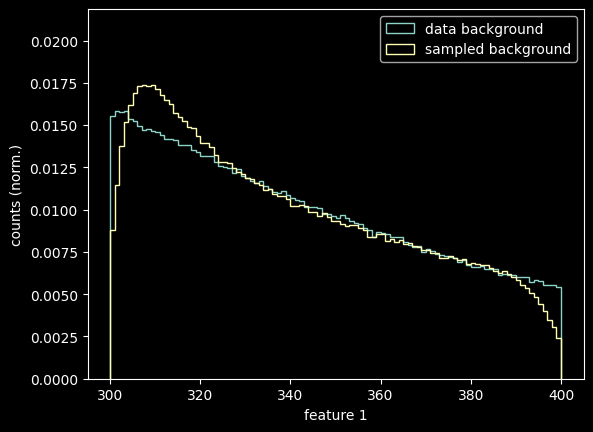

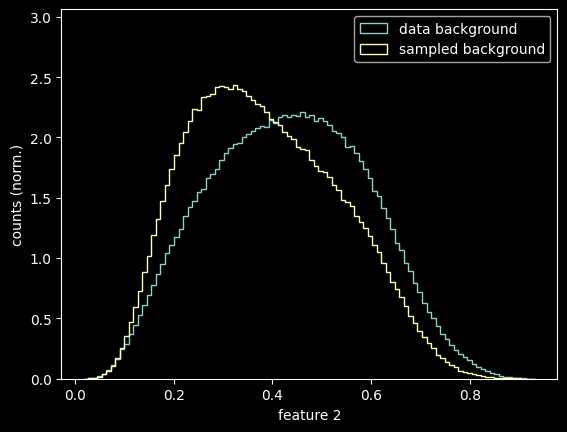

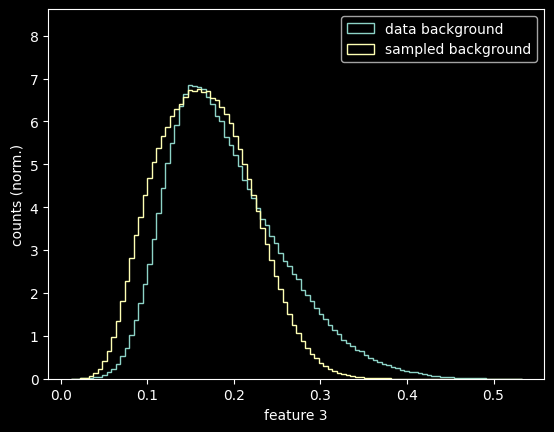

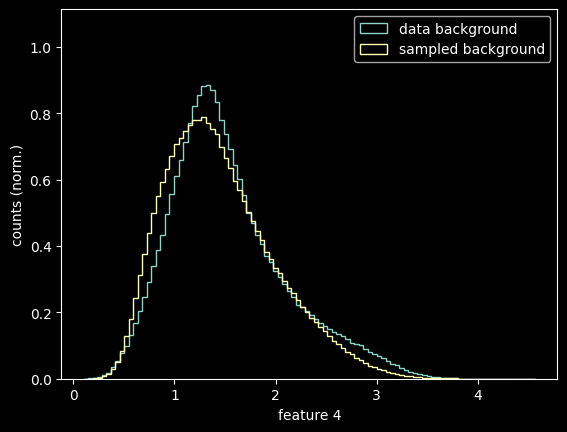

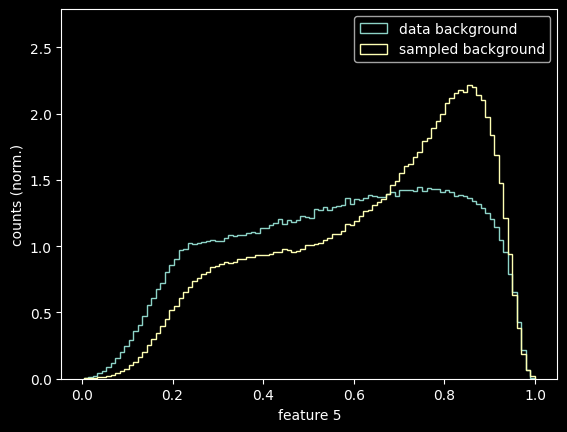

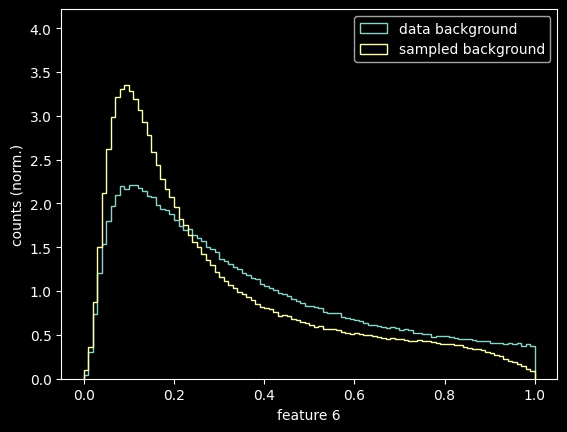

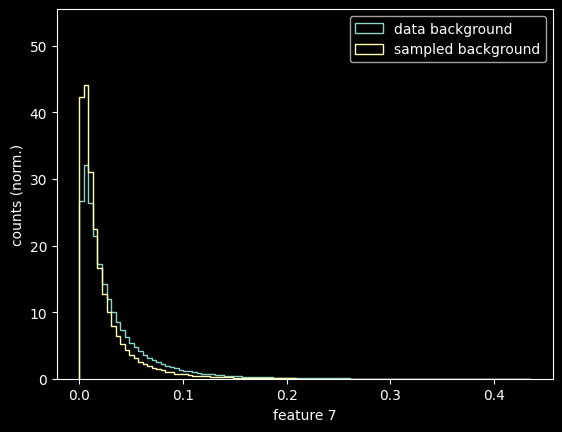

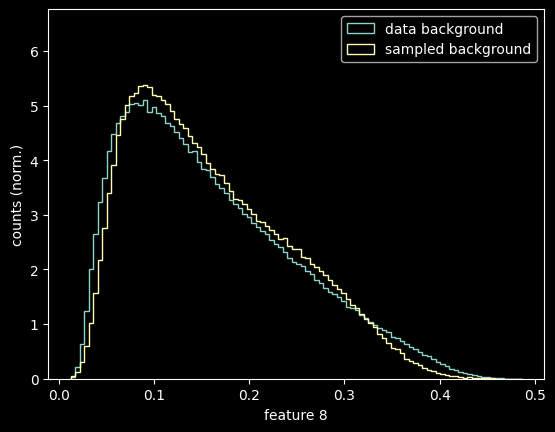

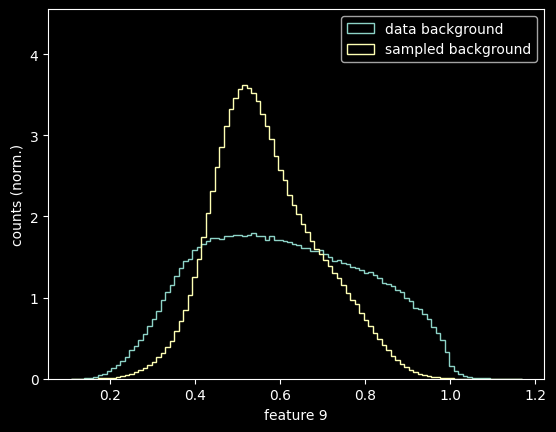

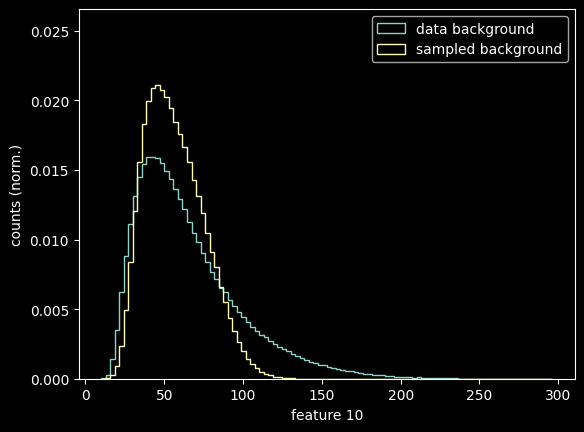

In [16]:
# comparing samples to inner background (idealized sanity check)

for i in range(cathode_samples_df.shape[1]):
    _, binning, _ = plt.hist(test_df[test_df["signal"] == 0].iloc[:, i],
                             bins=100, label="data background",
                             density=True, histtype="step")
    _ = plt.hist(cathode_samples_df.iloc[:, i],
                 bins=binning, label="sampled background",
                 density=True, histtype="step")
    plt.legend()
    plt.ylim(0, plt.gca().get_ylim()[1] * 1.2)
    plt.xlabel("feature {}".format(i))
    plt.ylabel("counts (norm.)")
    plt.show()

In [17]:
# assigning "signal" label 1 to data
clsf_train_data = innerdata_train.copy()
clsf_train_data[:, -1] = np.ones_like(clsf_train_data[:, -1])

clsf_val_data = innerdata_val.copy()
clsf_val_data[:, -1] = np.ones_like(clsf_val_data[:, -1])

# then mixing data and samples into train/val sets together proportionally
n_train = len(clsf_train_data)
n_val = len(clsf_val_data)
n_samples_train = int(n_train / (n_train + n_val) * len(samples))
samples_train = samples[:n_samples_train]
samples_val = samples[n_samples_train:]

clsf_train_set = np.vstack([clsf_train_data, samples_train])
clsf_val_set = np.vstack([clsf_val_data, samples_val])
clsf_train_set = shuffle(clsf_train_set, random_state=42)
clsf_val_set = shuffle(clsf_val_set, random_state=42)

# Train Classifier

Train a classifier to differentiate between the "true" SR data, and the sampled SR data that was learnt by the normalizing flow.

In [18]:
# either train new NN classifier to distinguish between real inner data and samples

# derive scaler parameters on data only, so it stays the same even if we resample
# inner_scaler = StandardScaler()
# inner_scaler.fit(clsf_train_data[:, 1:-1])

# X_train = inner_scaler.transform(clsf_train_set[:, 1:-1])
X_train = clsf_train_set[:, 1:-1]
y_train = clsf_train_set[:, -1]
# X_val = inner_scaler.transform(clsf_val_set[:, 1:-1]) 
X_val = clsf_val_set[:, 1:-1]
y_val = clsf_val_set[:, -1]

classifier_savedir = "./trained_classifiers_deltaR_CATHODE/"
# Let's protect ourselves from accidentally overwriting a trained model.
if not exists(join(classifier_savedir, "CLSF_models")):
    classifier_model = NeuralNetworkClassifier(save_path=classifier_savedir,
                                               n_inputs=X_train.shape[1],
                                               early_stopping=True, epochs=None,
                                               verbose=True)
    classifier_model.fit(X_train, y_train, X_val, y_val)
else:
    print(f"The model exists already in {classifier_savedir}. Remove first if you want to overwrite.")

The model exists already in ./trained_classifiers_deltaR_CATHODE/. Remove first if you want to overwrite.


In [19]:
# or alternatively load existing classifer model

# inner_scaler = StandardScaler()
# inner_scaler.fit(clsf_train_data[:, 1:-1])

classifier_savedir = "./trained_classifiers_deltaR_CATHODE/"
classifier_model = NeuralNetworkClassifier(save_path=classifier_savedir,
                                           n_inputs=clsf_train_data[:, 1:-1].shape[1],
                                           load=True)

# CDOT Training (CATHODE)




In [20]:
#CDOT

# Use the validation dataset for CDOT training
cdot_data = np.vstack((outerdata_val, innerdata_val))

cdot_data = cdot_data[cdot_data[:, -1] == 0]

# X_cdot = inner_scaler.transform(cdot_data[:, 1:-1])
X_cdot = cdot_data[:, 1:-1]
m_cdot = cdot_data[:, 0]

preds_cdot = classifier_model.predict(X_cdot)

# Fit the conditional kernel density estimate
cdot_model = sm.nonparametric.KDEMultivariateConditional(endog = preds_cdot, exog = m_cdot, dep_type='c', indep_type='c', bw=[0.001, 0.001])

In [21]:
bw = cdot_model.bw
bw

array([0.001, 0.001])

# Classifier Outputs

In [22]:
# Train set (pre-CDOT) classifier outputs

X_train = train_df.iloc[:, 1:11].to_numpy()

h_train = classifier_model.predict(X_train)

train_df["h"] = h_train

In [23]:
# Validation set (pre-CDOT) classifier outputs

X_val = val_df.iloc[:, 1:11].to_numpy()

h_val = classifier_model.predict(X_val)

val_df["h"] = h_val

In [24]:
# Test set (pre-CDOT) classifier outputs

X_test = test_df.iloc[:, 1:11].to_numpy()

h_test = classifier_model.predict(X_test)

test_df["h"] = h_test

# CDOT transformed classifier outputs (uniform)

In [25]:
# Training set (CDOT) transformed classifier outputs

m_train = train_df["mass"].to_numpy()

trans_h_train = cdot_model.cdf(h_train, m_train)

train_df["trans_h"] = trans_h_train

In [26]:
# Validation set (CDOT) transformed classifier outputs

m_val = val_df["mass"].to_numpy()

trans_h_val = cdot_model.cdf(h_val, m_val)

val_df["trans_h"] = trans_h_val

In [27]:
# Test set (CDOT) transformed classifier outputs

m_test = test_df["mass"].to_numpy()

trans_h_test= cdot_model.cdf(h_test, m_test)

test_df["trans_h"] = trans_h_test

# CDOT transformed classifier outputs (inverse quantile)

In [28]:
# Training set (CDOT) inverse transformed classifier outputs

# Take any values slightly above 1 and make them 1
trans_h_train = np.clip(trans_h_train, None, 1)


train_df["inv_trans_h"] = np.quantile(preds_cdot, trans_h_train)

In [29]:
# Validation set (CDOT) inverse transformed classifier outputs

# Take any values slightly above 1 and make them 1
trans_h_val = np.clip(trans_h_val, None, 1)

val_df["inv_trans_h"] = np.quantile(preds_cdot, trans_h_val)

In [30]:
# Test set (CDOT) inverse transformed classifier outputs

# Take any values slightly above 1 and make them 1
trans_h_test = np.clip(trans_h_test, None, 1)

test_df["inv_trans_h"] = np.quantile(preds_cdot, trans_h_test)

# Train Idealised Classifier

In [31]:
# either train new NN classifier to distinguish between real inner data and samples

# derive scaler parameters on data only, so it stays the same even if we resample
# inner_scaler = StandardScaler()
# inner_scaler.fit(clsf_train_data[:, 1:-1])

# X_train = inner_scaler.transform(clsf_train_set[:, 1:-1])
X_train = train_df[list(train_df.columns)[1:11]].to_numpy()
y_train = train_df["signal"].to_numpy()
# X_val = inner_scaler.transform(clsf_val_set[:, 1:-1]) 
X_val = val_df[list(train_df.columns)[1:11]].to_numpy()
y_val = val_df["signal"].to_numpy()

idealised_classifier_savedir = "./trained_classifiers_deltaR_idealised/"
# Let's protect ourselves from accidentally overwriting a trained model.
if not exists(join(idealised_classifier_savedir, "CLSF_models")):
    idealised_classifier_model = NeuralNetworkClassifier(save_path=idealised_classifier_savedir,
                                               n_inputs=X_train.shape[1],
                                               early_stopping=True, epochs=None,
                                               verbose=True)
    idealised_classifier_model.fit(X_train, y_train, X_val, y_val)
else:
    print(f"The model exists already in {idealised_classifier_savedir}. Remove first if you want to overwrite.")

The model exists already in ./trained_classifiers_deltaR_idealised/. Remove first if you want to overwrite.


In [32]:
# or alternatively load existing classifer model

# inner_scaler = StandardScaler()
# inner_scaler.fit(clsf_train_data[:, 1:-1])

idealised_classifier_savedir = "./trained_classifiers_deltaR_idealised/"
idealised_classifier_model = NeuralNetworkClassifier(save_path=idealised_classifier_savedir,
                                           n_inputs=X_train.shape[1],
                                           load=True)

# CDOT Training (Idealised Classifier)

In [33]:
# #CDOT

# # Use the validation dataset for CDOT training

# cdot_data = np.vstack((outerdata_val, innerdata_val), )

# cdot_data = cdot_data[cdot_data[:, -1] == 0]

# # X_cdot = inner_scaler.transform(cdot_data[:, 1:-1])
# X_cdot = cdot_data[:, 1:-1]
# m_cdot = cdot_data[:, 0]

preds_cdot_idealised = idealised_classifier_model.predict(X_cdot)

preds_cdot_idealised_logit = np.log(preds_cdot_idealised/ (1-preds_cdot_idealised))

# Fit the conditional kernel density estimate
cdot_model_idealised = sm.nonparametric.KDEMultivariateConditional(endog = preds_cdot_idealised, exog = m_cdot, dep_type='c', indep_type='c', bw=[0.001, 0.001])

In [34]:
bw_ideal = cdot_model_idealised.bw
bw_ideal

array([0.001, 0.001])

# Idealised Classifier Outputs

In [35]:
# Train set (pre-CDOT) classifier outputs

X_train = train_df.iloc[:, 1:11].to_numpy()

h_train_idealised = idealised_classifier_model.predict(X_train)

train_df["ideal_h"] = h_train_idealised

In [36]:
# Validation set (pre-CDOT) classifier outputs

X_val = val_df.iloc[:, 1:11].to_numpy()

h_val_idealised = idealised_classifier_model.predict(X_val)

val_df["ideal_h"] = h_val_idealised

In [37]:
# Test set (pre-CDOT) classifier outputs

X_test = test_df.iloc[:, 1:11].to_numpy()

h_test_idealised = idealised_classifier_model.predict(X_test)

test_df["ideal_h"] = h_test_idealised

# CDOT Transformed Idealised Classifier Outputs

In [38]:
# Training set (CDOT) transformed classifier outputs

m_train = train_df["mass"].to_numpy()

idealised_h_train_logit = np.log(h_train_idealised / (1-h_train_idealised))

trans_h_train_idealised = cdot_model_idealised.cdf(h_train_idealised, m_train)

# trans_h_train_idealised = cdot_model_idealised.cdf(h_train_idealised, m_train)

train_df["trans_ideal_h"] = trans_h_train_idealised

In [39]:
# Validation set (CDOT) transformed classifier outputs

m_val = val_df["mass"].to_numpy()

idealised_h_val_logit = np.log(h_val_idealised / (1 - h_val_idealised))

trans_h_val_idealised = cdot_model_idealised.cdf(h_val_idealised, m_val)

val_df["trans_ideal_h"] = trans_h_val_idealised

In [40]:
# Test set (CDOT) transformed classifier outputs

m_test = test_df["mass"].to_numpy()

idealised_h_test_logit = np.log(h_test_idealised / (1 - h_test_idealised))

trans_h_test_idealised = cdot_model_idealised.cdf(h_test_idealised, m_test)

test_df["trans_ideal_h"] = trans_h_test_idealised

# CDOT Inverse Transformed Idealised Classifier Outputs

In [41]:
# Training set (CDOT) inverse transformed classifier outputs

# Take any values slightly above 1 and make them 1
trans_h_train_idealised = np.clip(trans_h_train_idealised, None, 1)

train_df["inv_trans_ideal_h"] = np.quantile(preds_cdot_idealised, trans_h_train_idealised)

In [42]:
# Validation set (CDOT) inverse transformed classifier outputs

# Take any values slightly above 1 and make them 1
trans_h_val_idealised = np.clip(trans_h_val_idealised, None, 1)

val_df["inv_trans_ideal_h"] = np.quantile(preds_cdot_idealised, trans_h_val_idealised)

In [43]:
# Test set (CDOT) inverse transformed classifier outputs

# Take any values slightly above 1 and make them 1
trans_h_test_idealised = np.clip(trans_h_test_idealised, None, 1)

test_df["inv_trans_ideal_h"] = np.quantile(preds_cdot_idealised, trans_h_test_idealised)

# LaCATHODE

Plot each variable/feature, split into the data from each respective region of the invariant mass $m$.
- Lower SB
- SR
- Upper SB

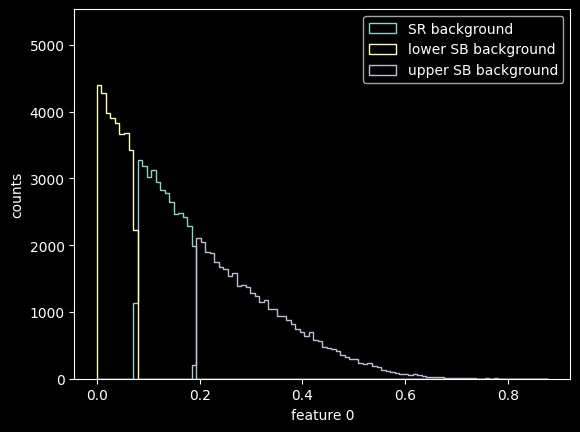

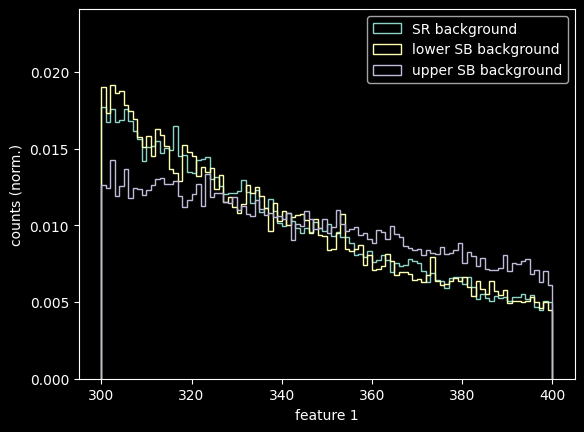

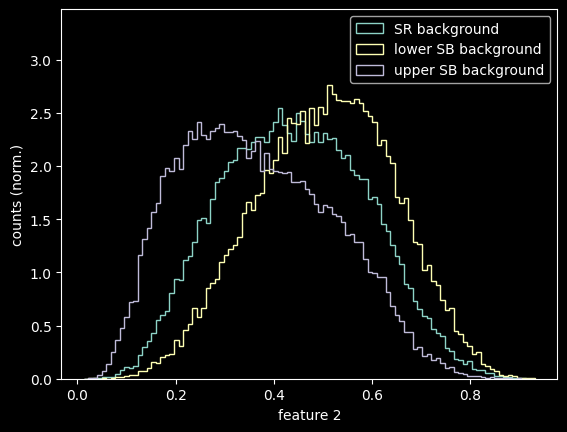

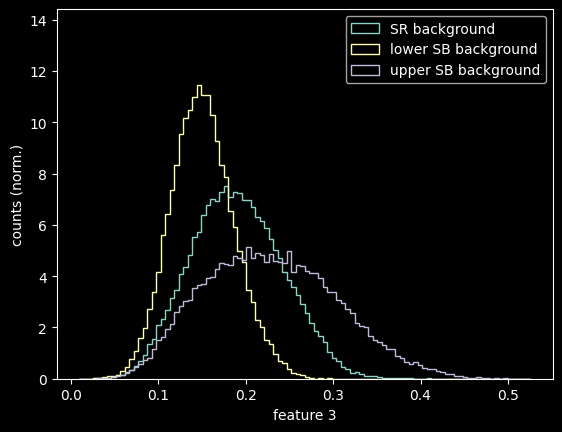

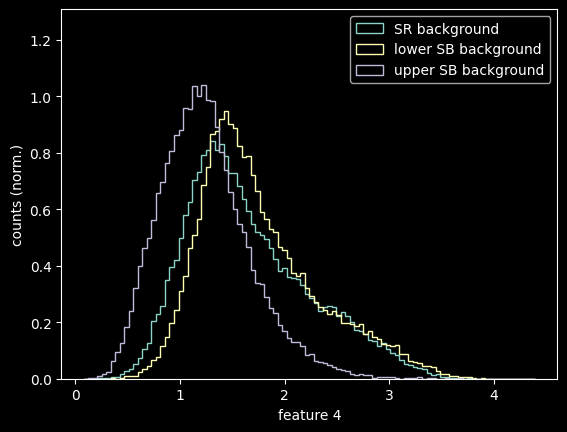

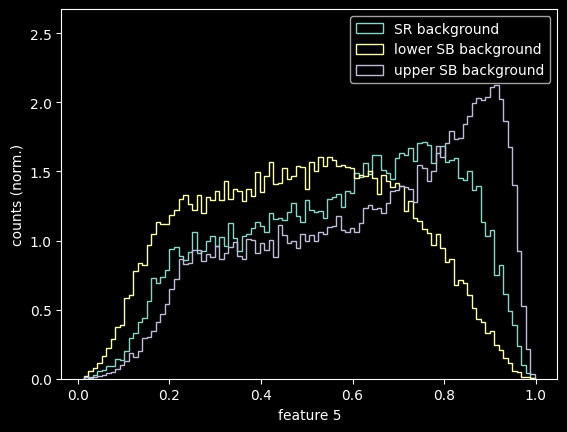

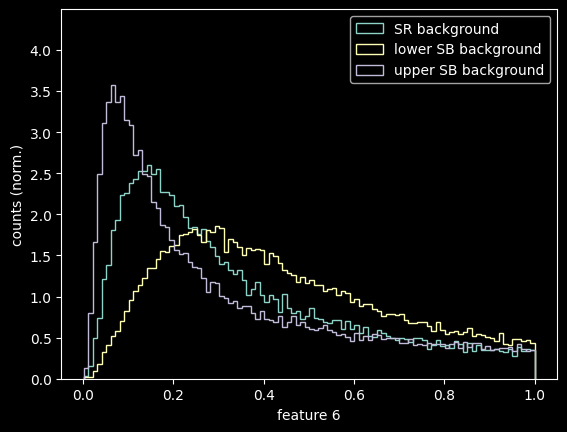

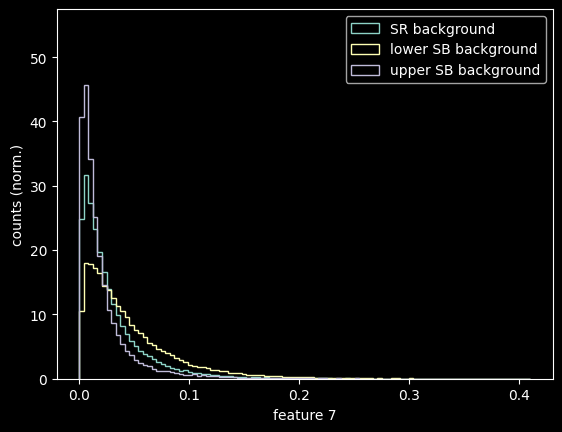

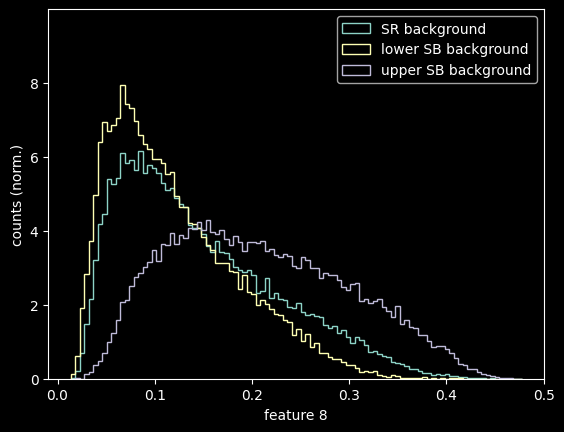

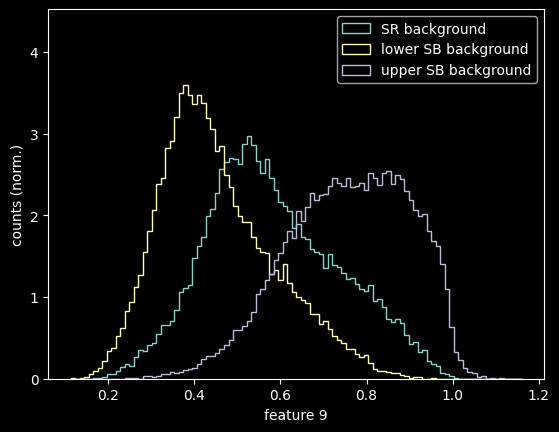

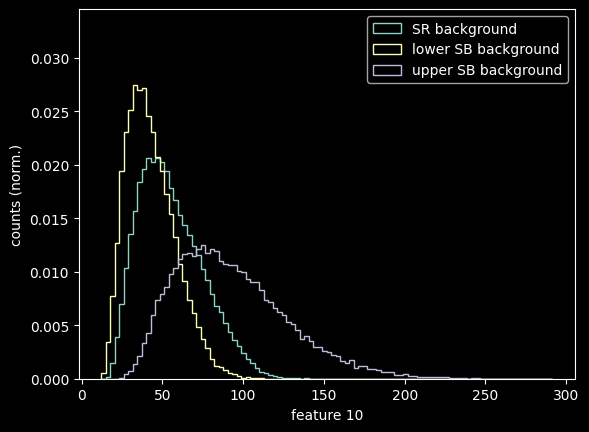

In [44]:
lowerdata_train = outerdata_train[outerdata_train[:, 0] < innerdata_train[:, 0].min()]
upperdata_train = outerdata_train[outerdata_train[:, 0] > innerdata_train[:, 0].max()]

for i in range(innerdata_train[:, :-1].shape[1]):
    # computing the binning on full outer data
    _, binning = np.histogram(outerdata_train[:, i], bins=100)
    _ = plt.hist(innerdata_train[innerdata_train[:, -1] == 0, i],
                 bins=binning, label="SR background",
                 density=True if i >0 else False, histtype="step")
    _ = plt.hist(lowerdata_train[lowerdata_train[:, -1] == 0, i],
                 bins=binning, label="lower SB background",
                 density=True if i >0 else False, histtype="step")
    _ = plt.hist(upperdata_train[upperdata_train[:, -1] == 0, i],
                 bins=binning, label="upper SB background",
                 density=True if i >0 else False, histtype="step")
    plt.legend()
    plt.ylim(0, plt.gca().get_ylim()[1] * 1.2)
    plt.xlabel("feature {}".format(i))
    plt.ylabel("counts (norm.)" if i > 0 else "counts")
    plt.show()

So while the first four auxiliary features (feature 1-4) seem quite similar in SR and SB, there is a siginificant difference between the three regions in $\Delta R_{jj}$ (feature 5). So there are clearly strong correlations between the input space of our neural network classifier and the resonant feature. Thus, the classifier will learn this dependence as well and our anomaly score inherits this correlation. Cutting on this anomaly score thus translates to some funny cut on the resonant feature. Looking at the plot above, we see that we even extrapolate the classifier into regions (SB) outside its training space (SR). Neural networks are not known to handle this type of extrapolation well.

We could either try to remove this correlation a-posteriori, or we could remove the correlation from the input features *before* the classifier training. The latter is something that we actually aready have lying around just from CATHODE. We trained a conditional normalizing flow, which is a function $f(x, m)$ that maps data space $x$ to the latent space $z$, which follows a standard normal distribution, and it does so continuously for every $m$. Thus, the $z$ and $m$ will be effectively decorrelated.

This is what we try to make use of in latent CATHODE (LaCATHODE). Before we train the CATHODE classifier, we move all the SR training data to the latent space using the learned flow model. The background should just be distributed like a standard gaussian, so the sampling becomes straightforward. Once we want to infer the anomaly score of our test data, we also first move it to the same latent space. SR and SB should be identically distributed there.

Let's do this in practice below:

In [45]:
# if necessary loading existing flow model again

# outer_scaler = make_pipeline(LogitScaler(), StandardScaler())
# outer_scaler.fit(outerdata_train[:, 1:-1])

flow_savedir = "./trained_flows_deltaR/"
flow_model = ConditionalNormalizingFlow(save_path=flow_savedir,
                                        num_inputs=outerdata_train[:, 1:-1].shape[1],
                                        load=True)

ConditionalNormalizingFlow has 309720 parameters
The best epoch is 99.


In [46]:
# move all the inner training and validation data to the latent space of the flow

latent_train_data = flow_model.transform(innerdata_train[:, 1:-1],
                                         m=innerdata_train[:, 0:1])
latent_val_data = flow_model.transform(innerdata_val[:, 1:-1],
                                       m=innerdata_val[:, 0:1])

# we know how perfect background samples should like in this space: a standard normal
latent_samples = np.random.randn(4*latent_train_data.shape[0], latent_train_data.shape[1])

In [47]:
latent_train_df = pd.DataFrame(latent_train_data, columns = ["x1", "x2", "x3", "x4", "x5", "x6", "x7", "x8", "x9", "x10"])

In [48]:
latent_sample_df = pd.DataFrame(latent_samples, columns = ["x1", "x2", "x3", "x4", "x5", "x6", "x7", "x8", "x9", "x10"])

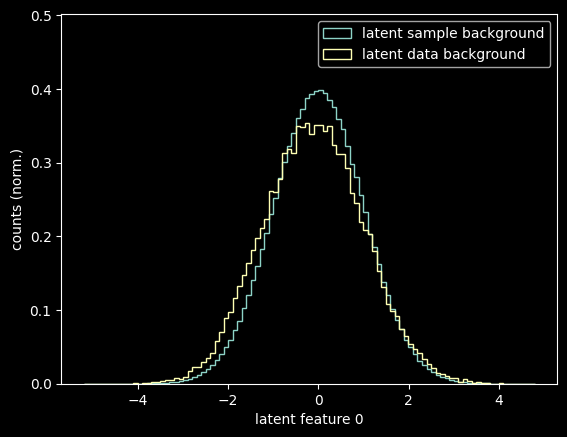

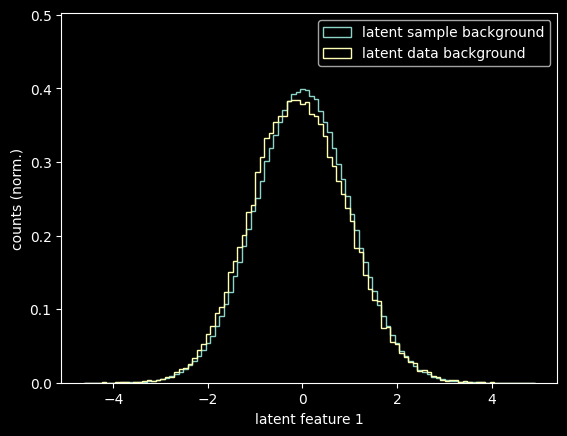

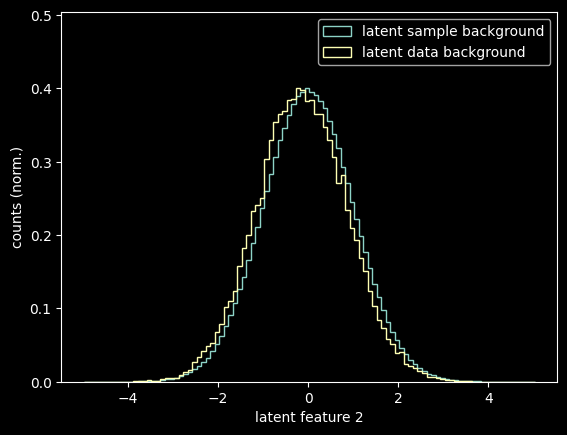

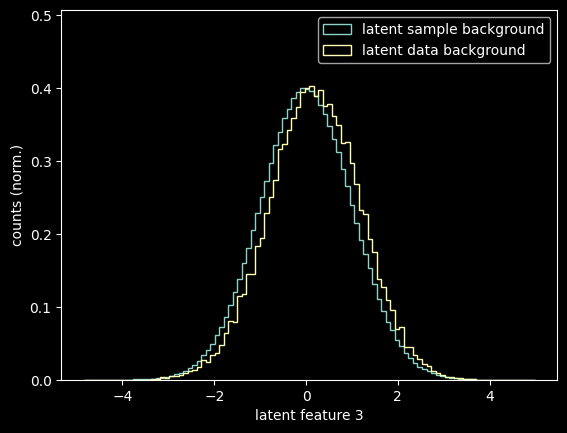

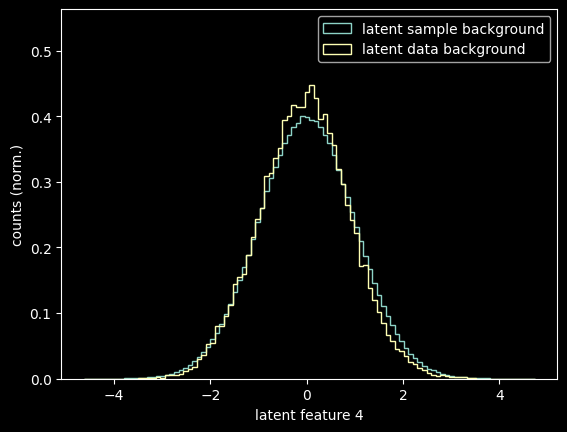

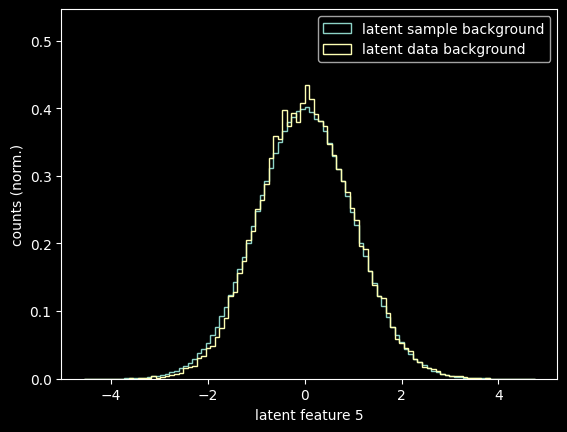

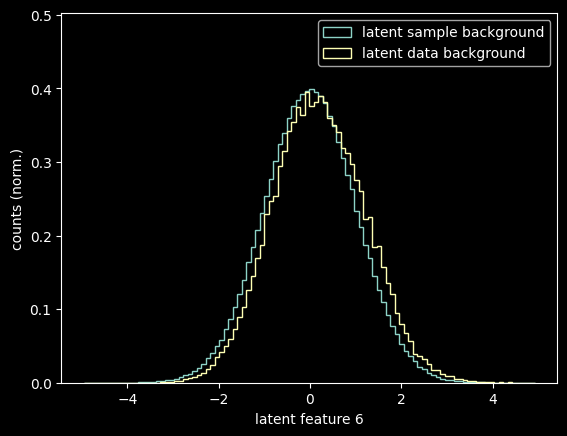

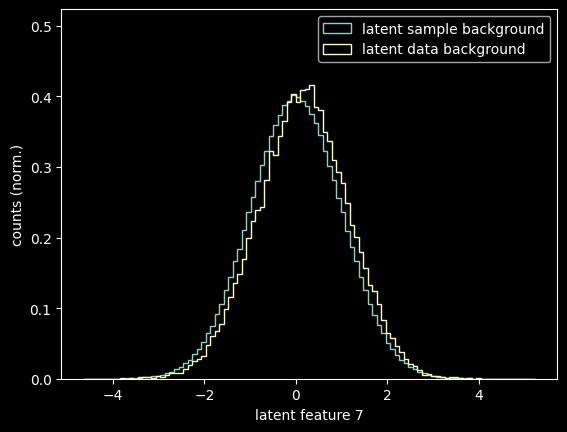

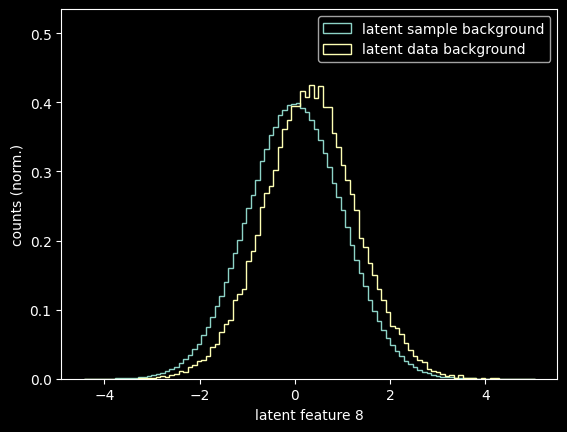

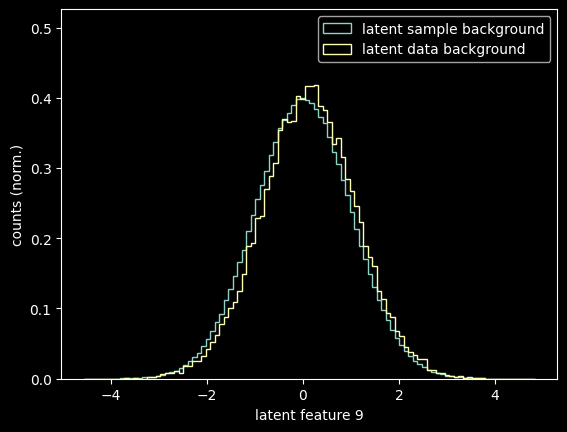

In [49]:
for i in range(latent_train_data.shape[1]):
    _, binning, _ = plt.hist(latent_samples[:, i],
                             bins=100, label="latent sample background",
                             density=True, histtype="step")
    _ = plt.hist(latent_train_data[innerdata_train[:, -1] == 0, i],
                 bins=binning, label="latent data background",
                 density=True, histtype="step")
    plt.legend()
    plt.ylim(0, plt.gca().get_ylim()[1] * 1.2)
    plt.xlabel("latent feature {}".format(i))
    plt.ylabel("counts (norm.)")
    plt.show()

In [50]:
# assigning "signal" label 1 to data and 0 to samples
clsf_latent_train_data = np.hstack([latent_train_data,
                                    np.ones((latent_train_data.shape[0], 1))])
clsf_latent_val_data = np.hstack([latent_val_data,
                                  np.ones((latent_val_data.shape[0], 1))])
clsf_latent_samples = np.hstack([latent_samples,
                                 np.zeros((latent_samples.shape[0], 1))])

# then mixing data and samples into train/val sets together proportionally
n_train = len(clsf_latent_train_data)
n_val = len(clsf_latent_val_data)
n_samples_train = int(n_train / (n_train + n_val) * len(clsf_latent_samples))
clsf_latent_samples_train = clsf_latent_samples[:n_samples_train]
clsf_latent_samples_val = clsf_latent_samples[n_samples_train:]

clsf_latent_train_set = np.vstack([clsf_latent_train_data, clsf_latent_samples_train])
clsf_latent_val_set = np.vstack([clsf_latent_val_data, clsf_latent_samples_val])
clsf_latent_train_set = shuffle(clsf_latent_train_set, random_state=42)
clsf_latent_val_set = shuffle(clsf_latent_val_set, random_state=42)

In [51]:
# either train new NN classifier to distinguish between real inner data and samples

# derive scaler parameters on data only, so it stays the same even if we resample
# latent_scaler = StandardScaler()
# latent_scaler.fit(clsf_latent_train_data[:, :-1])

# X_train = latent_scaler.transform(clsf_latent_train_set[:, :-1])
X_train = clsf_latent_train_set[:, :-1]
y_train = clsf_latent_train_set[:, -1]
# X_val = latent_scaler.transform(clsf_latent_val_set[:, :-1])
X_val = clsf_latent_val_set[:, :-1]
y_val = clsf_latent_val_set[:, -1]

latent_classifier_savedir = "./trained_classifiers_deltaR_LaCATHODE/"
# Let's protect ourselves from accidentally overwriting a trained model.
if not exists(join(latent_classifier_savedir, "CLSF_models")):
    latent_classifier_model = NeuralNetworkClassifier(save_path=latent_classifier_savedir,
                                                      n_inputs=X_train.shape[1],
                                                      early_stopping=True, epochs=None,
                                                      verbose=True)
    latent_classifier_model.fit(X_train, y_train, X_val, y_val)
else:
    print(f"The model exists already in {latent_classifier_savedir}. Remove first if you want to overwrite.")

The model exists already in ./trained_classifiers_deltaR_LaCATHODE/. Remove first if you want to overwrite.


In [52]:
# or alternatively load existing classifer model

latent_scaler = StandardScaler()
latent_scaler.fit(clsf_latent_train_data[:, :-1])

latent_classifier_savedir = "./trained_classifiers_deltaR_LaCATHODE/"
latent_classifier_model = NeuralNetworkClassifier(save_path=latent_classifier_savedir,
                                                  n_inputs=clsf_latent_train_data[:, :-1].shape[1],
                                                  load=True)

In [53]:
# We will now first map data through the flow and its preprocessing and then
# through the classifier and its preprocessing to get the final prediction.
# Let's simplify this chain with a single pipeline.

# lacathode_predictor = make_pipeline(outer_scaler,
#                                     flow_model,
#                                     latent_scaler,
#                                     latent_classifier_model)

lacathode_predictor = make_pipeline(
                                    flow_model,
                                    latent_classifier_model)

# LaCATHODE classifier outputs

In [54]:
# Train Set LaCATHODE classifier outputs

X_train = train_df.iloc[:, 1:11].to_numpy()

m_train = train_df[["mass"]].to_numpy()

la_h_train = lacathode_predictor.predict(X_train, m=m_train).flatten()

train_df["la_h"] = la_h_train

In [55]:
# Validation Set LaCATHODE classifier outputs

X_val = val_df.iloc[:, 1:11].to_numpy()

m_val = val_df[["mass"]].to_numpy()

la_h_val = lacathode_predictor.predict(X_val, m=m_val).flatten()

val_df["la_h"] = la_h_val

In [56]:
# Test Set LaCATHODE classifier outputs

X_test = test_df.iloc[:, 1:11].to_numpy()

m_test = test_df[["mass"]].to_numpy()

la_h_test = lacathode_predictor.predict(X_test, m=m_test).flatten()

test_df["la_h"] = la_h_test

# Save the DataFrames

In [57]:
train_df.to_pickle("./train.pkl")

In [58]:
val_df.to_pickle("./val.pkl")

In [59]:
test_df.to_pickle("./test.pkl")

In [60]:
cathode_samples_df.to_pickle("./cathode_samples.pkl")

In [61]:
latent_train_df.to_pickle("./LaCATHODE_train.pkl")

In [62]:
latent_sample_df.to_pickle("./LaCATHODE_samples.pkl")